# 04 — Business Analysis

Chạy sau khi `src/segmentation.py` + `src/export_segments.py` đã chạy xong (hoặc `python main.py`).

**Format:** mỗi phần đi theo storytelling —
```
Business Question -> SQL/Data -> Visualization -> Insight -> Recommendation
```
6 câu hỏi kinh doanh cốt lõi, kết thúc bằng Executive Summary tổng hợp.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

from src.database import get_engine
from src.recommendation import generate_recommendations

sns.set_style('whitegrid')
engine = get_engine()

2026-08-09 20:12:54 | INFO     | src.database | Created SQLAlchemy engine for PostgreSQL.


---
# Câu hỏi 1: Category nào tạo ra doanh thu cao nhất?

In [2]:
q1_df = pd.read_sql(text('SELECT * FROM category_sales ORDER BY revenue DESC LIMIT 10'), engine)
q1_df

,category,items_sold,revenue
0,health_beauty,9465,1233131.72
1,watches_gifts,5859,1166176.98
2,bed_bath_table,10953,1023434.76
3,sports_leisure,8431,954852.55
4,computers_accessories,7644,888724.61
5,furniture_decor,8160,711927.69
6,housewares,6795,615628.69
7,cool_stuff,3718,610204.10
8,auto,4140,578966.65
9,toys,4030,471286.48


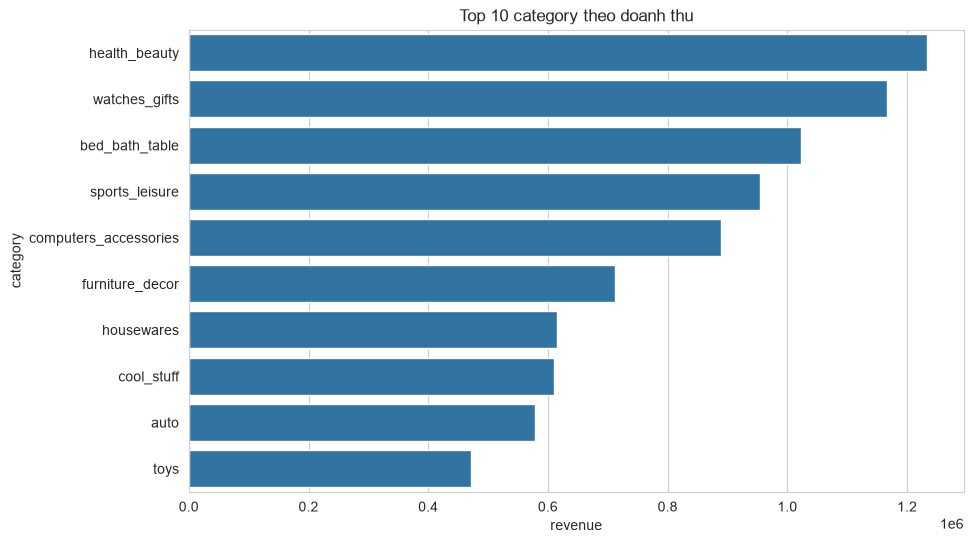

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=q1_df, y='category', x='revenue')
plt.title('Top 10 category theo doanh thu')
plt.show()

**Insight:** *(điền sau khi chạy)* top 3 category chiếm ___% tổng doanh thu — hiệu ứng Pareto
rõ rệt ở cấp category, tương tự pattern đã thấy ở cấp khách hàng.

**Recommendation:** ưu tiên tồn kho, quảng cáo, và deal với seller cho top category; với category
cuối bảng, cân nhắc giảm số lượng SKU hoặc đàm phán lại chi phí vận hành.

---
# Câu hỏi 2: Segment khách hàng nào đóng góp doanh thu nhiều nhất?

In [4]:
segments = pd.read_sql(text('SELECT * FROM customer_segments'), engine)

q2_df = segments.groupby('segment_name').agg(
    num_customers=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
).reset_index()
q2_df['pct_customers'] = (q2_df['num_customers'] / q2_df['num_customers'].sum() * 100).round(1)
q2_df['pct_revenue'] = (q2_df['total_revenue'] / q2_df['total_revenue'].sum() * 100).round(1)
q2_df.sort_values('total_revenue', ascending=False)

,segment_name,num_customers,total_revenue,pct_customers,pct_revenue
0,Active One-Time Customers,50642,6804260.66,54.2,44.1
1,Dormant Customers,37526,5008135.91,40.2,32.5
2,High-Value Potential,2418,2807071.54,2.6,18.2
3,Loyal Customers,2772,802993.66,3.0,5.2


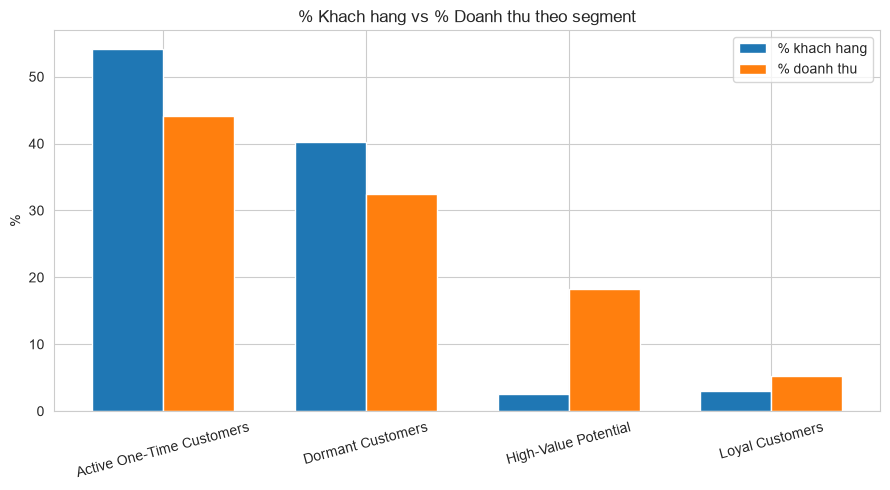

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(q2_df))
width = 0.35
ax.bar([i - width/2 for i in x], q2_df['pct_customers'], width, label='% khach hang')
ax.bar([i + width/2 for i in x], q2_df['pct_revenue'], width, label='% doanh thu')
ax.set_xticks(list(x))
ax.set_xticklabels(q2_df['segment_name'], rotation=15)
ax.set_ylabel('%')
ax.set_title('% Khach hang vs % Doanh thu theo segment')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** `High-Value Potential` chỉ chiếm 2.6% khách hàng nhưng đóng góp 18.2% doanh thu —
gấp ~7 lần tỷ trọng khách hàng của nó. Ngược lại, `Active One-Time Customers` chiếm 54.2% khách
hàng nhưng "chỉ" đóng góp 44.1% doanh thu (dưới tỷ trọng khách hàng) — bằng chứng định lượng rõ
ràng cho nguyên lý Pareto trong tệp khách hàng.

**Recommendation:** phân bổ ngân sách marketing tỷ lệ thuận với % đóng góp doanh thu, không chia
đều cho tất cả segment — ưu tiên cross-sell cho `High-Value Potential` (ROI/khách cao nhất).

---
# Câu hỏi 3: State nào nên ưu tiên cho marketing?

In [6]:
q3_df = pd.read_sql(text('SELECT * FROM state_sales ORDER BY revenue DESC LIMIT 10'), engine)
q3_df['revenue_per_customer'] = (q3_df['revenue'] / q3_df['num_customers']).round(2)
q3_df

,customer_state,num_customers,total_orders,revenue,revenue_per_customer
0,SP,39156,40501,5770266.19,147.37
1,RJ,11917,12350,2055690.45,172.50
2,MG,11001,11354,1819277.61,165.37
3,RS,5168,5345,861802.40,166.76
4,PR,4769,4923,781919.55,163.96
5,SC,3449,3546,595208.40,172.57
6,BA,3158,3256,591270.60,187.23
7,DF,2019,2080,346146.17,171.44
8,GO,1895,1957,334294.22,176.41
9,ES,1928,1995,317682.65,164.77


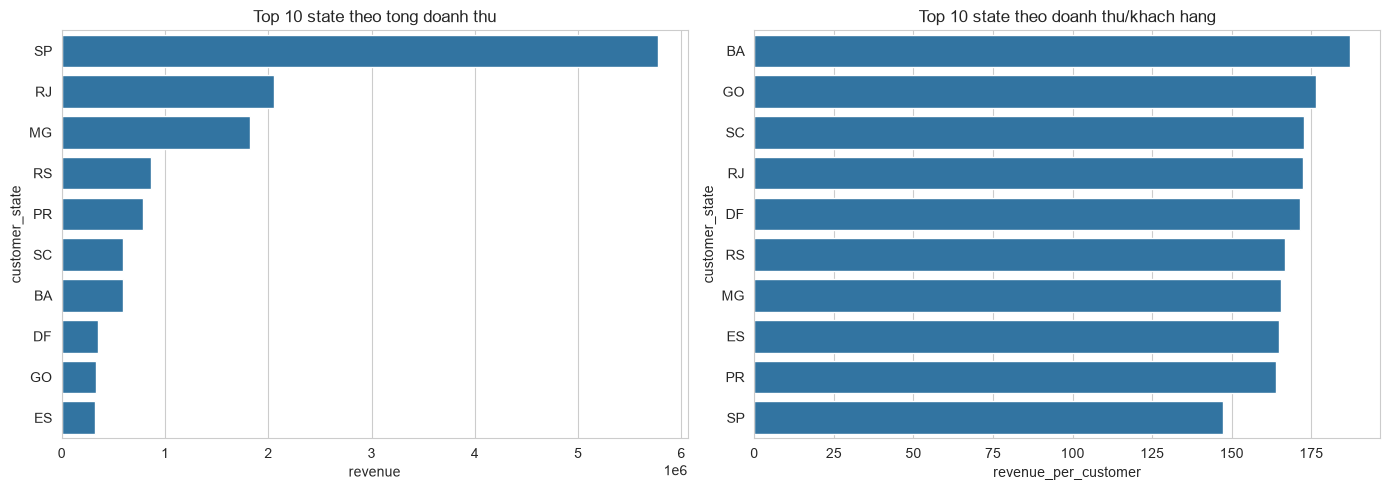

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=q3_df, y='customer_state', x='revenue', ax=axes[0])
axes[0].set_title('Top 10 state theo tong doanh thu')

sns.barplot(data=q3_df.sort_values('revenue_per_customer', ascending=False),
            y='customer_state', x='revenue_per_customer', ax=axes[1])
axes[1].set_title('Top 10 state theo doanh thu/khach hang')
plt.tight_layout()
plt.show()

**Insight:** *(điền sau khi chạy)* state dẫn đầu về tổng doanh thu không nhất thiết là state có
doanh thu/khách hàng cao nhất — 2 chiến lược khác nhau: mở rộng số lượng khách ở state đông, hay
tăng giá trị đơn ở state ít khách nhưng chi tiêu cao.

**Recommendation:** với state top tổng doanh thu → duy trì/mở rộng logistics. Với state có
doanh thu/khách cao nhưng ít khách → thử nghiệm tăng ngân sách acquisition, tiềm năng ROI tốt.

---
# Câu hỏi 4: Nhóm khách hàng mới mua 1 lần có cơ hội chuyển đổi thành repeat buyer không?
(trước đây gọi là "At Risk" — đổi câu hỏi vì dữ liệu cho thấy đây là khách MỚI, không phải khách
đang rời bỏ, xem giải thích ở `src/export_segments.py`)

In [8]:
active_one_time = segments[segments['segment_name'] == 'Active One-Time Customers']

print('So khach hang Active One-Time:', len(active_one_time))
print('Tong gia tri (monetary) cua nhom nay:', round(active_one_time['monetary'].sum(), 2))
print('Recency trung binh (ngay):', round(active_one_time['recency_days'].mean(), 1))

So khach hang Active One-Time: 50642
Tong gia tri (monetary) cua nhom nay: 6804260.66
Recency trung binh (ngay): 128.1


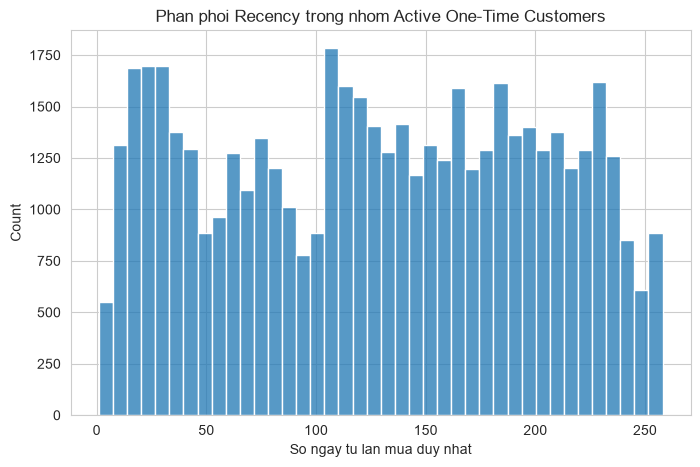

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(active_one_time['recency_days'], bins=40)
plt.title('Phan phoi Recency trong nhom Active One-Time Customers')
plt.xlabel('So ngay tu lan mua duy nhat')
plt.show()

**Insight:** nhóm `Active One-Time Customers` chiếm 54.2% khách hàng (50,642 người), đóng góp
44.1% tổng doanh thu — đây là nhóm LỚN NHẤT trong 4 segment. Recency trung bình 128.07 ngày (thấp
nhất trong 4 nhóm, nghĩa là mua tương đối gần đây), nhưng frequency=1.00 — chưa từng quay lại mua
lần 2. Đây không phải "khách sắp mất" mà là "khách mới chưa được thuyết phục mua lần 2".

**Recommendation:** ưu tiên chiến dịch second-purchase conversion (voucher cho đơn thứ 2, email
nhắc sau X ngày kể từ đơn đầu) thay vì win-back — vì đây là nhóm cơ hội chuyển đổi, không phải nhóm
cần "cứu vãn". Với quy mô 54.2% khách hàng, dù tỷ lệ chuyển đổi tăng nhẹ cũng tạo tác động lớn.

---
# Câu hỏi 5: Hành vi thanh toán nào liên quan đến chi tiêu cao hơn?

In [10]:
q5_query = """
SELECT op.payment_type, op.payment_installments, p.total_payment_value
FROM order_payments op
JOIN payments_per_order p ON p.order_id = op.order_id
WHERE op.payment_type != 'not_defined';
"""
q5_df = pd.read_sql(text(q5_query), engine)

q5_summary = q5_df.groupby('payment_type')['total_payment_value'].mean().sort_values(ascending=False)
q5_summary

payment_type
credit_card    167.174987
boleto         145.034435
debit_card     142.667632
voucher        141.309733
Name: total_payment_value, dtype: float64

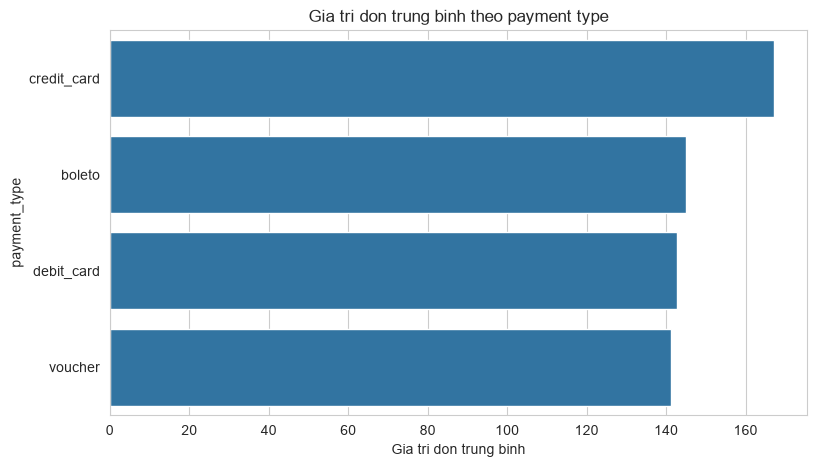

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(x=q5_summary.values, y=q5_summary.index)
plt.title('Gia tri don trung binh theo payment type')
plt.xlabel('Gia tri don trung binh')
plt.show()

**Insight:** *(điền sau khi chạy)* phương thức thanh toán liên quan đến giá trị đơn cao nhất là
___ — có thể do đây là phương thức phổ biến cho đơn giá trị lớn (VD: credit_card cho phép trả góp).

**Recommendation:** ưu tiên hiển thị/khuyến khích phương thức thanh toán này ở bước checkout,
đặc biệt cho giỏ hàng giá trị cao — có thể tăng conversion rate.

---
# Câu hỏi 6: Giao hàng chậm ảnh hưởng đến khách hàng như thế nào?

In [12]:
q6_query = """
SELECT
    EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_purchase_timestamp)) AS delivery_days,
    r.review_score
FROM orders o
JOIN order_reviews r ON r.order_id = o.order_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL;
"""
q6_df = pd.read_sql(text(q6_query), engine).dropna()

late_threshold = q6_df['delivery_days'].quantile(0.75)
q6_df['delivery_group'] = q6_df['delivery_days'].apply(
    lambda d: 'Giao cham (top 25%)' if d > late_threshold else 'Giao dung/nhanh'
)
q6_df.groupby('delivery_group')['review_score'].mean().round(2)

delivery_group
Giao cham (top 25%)    3.57
Giao dung/nhanh        4.34
Name: review_score, dtype: float64

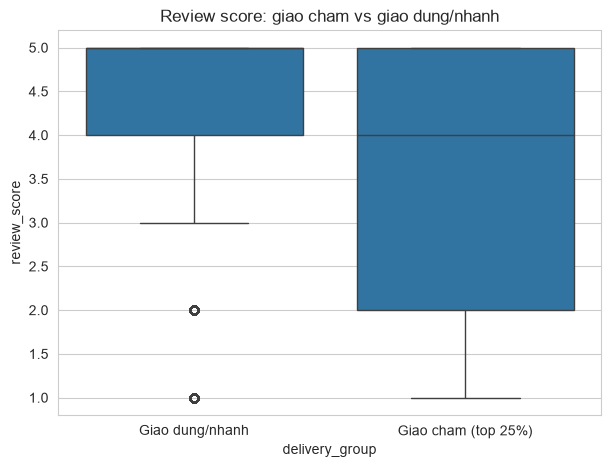

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=q6_df, x='delivery_group', y='review_score')
plt.title('Review score: giao cham vs giao dung/nhanh')
plt.show()

**Insight:** *(điền sau khi chạy, đối chiếu với kiểm định Spearman ở `02_statistical_analysis.ipynb`)*
nhóm giao chậm (top 25% thời gian giao) có review trung bình thấp hơn ___ điểm so với nhóm giao
đúng/nhanh.

**Recommendation:** đặt SLA cảnh báo nội bộ cho đơn có nguy cơ rơi vào top 25% thời gian giao —
chủ động thông báo khách hàng thay vì để họ bất ngờ, giảm thiểu tác động tới review.

---
# Segment Profiling đầy đủ (bổ sung số liệu chi tiết)

In [14]:
profile = segments.groupby('segment_name').agg(
    num_customers=('customer_unique_id', 'count'),
    avg_recency_days=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_monetary=('monetary', 'sum'),
).round(2).sort_values('avg_monetary', ascending=False)
profile

,num_customers,avg_recency_days,avg_frequency,avg_monetary,total_monetary
segment_name,,,,,
High-Value Potential,2418,239.40,1.01,1160.91,2807071.54
Loyal Customers,2772,220.44,2.11,289.68,802993.66
Active One-Time Customers,50642,128.07,1.00,134.36,6804260.66
Dormant Customers,37526,387.41,1.00,133.46,5008135.91


**Lưu ý về Customer Lifetime insight:** `avg_monetary` ở trên là giá trị đã thực hiện tính đến
hiện tại (historical value), không phải CLV dự báo tương lai — CLV dự báo cần thêm giả định về
churn rate/thời gian sống còn lại, nằm ngoài phạm vi RFM cơ bản (ghi vào `docs/methodology.md`
phần Future Work).

---
# Business Recommendations tổng hợp theo segment

In [15]:
recs = generate_recommendations(profile.reset_index())
for segment, rec in recs.items():
    print(f'=== {segment} ===')
    print(rec)
    print()

2026-08-09 20:12:58 | INFO     | src.recommendation | Generated recommendations for 4 segments.


=== High-Value Potential ===
Chỉ chiếm phần nhỏ khách hàng nhưng monetary trung bình cao vượt trội (gấp ~4 lần Loyal Customers) dù hầu như mới mua 1 lần (frequency ~1). Đây là nhóm 'chi mạnh tay nhưng chưa quay lại' — ưu tiên cross-sell / personalized offer để thúc đẩy mua lần 2, biến giá trị đơn lẻ cao thành mối quan hệ dài hạn.

=== Loyal Customers ===
Frequency cao nhất trong 4 segment (đặt lại đơn nhiều lần), dù chi tiêu trung bình mỗi đơn không phải cao nhất. Ưu tiên VIP Campaign / chương trình loyalty: giữ chân nhóm đã chứng minh hành vi mua lặp lại thật sự, chi phí giữ chân nhóm này thường rẻ hơn thu hút khách mới.

=== Active One-Time Customers ===
Chiếm tỷ trọng khách hàng lớn nhất, mới mua gần đây (recency thấp nhất trong 4 nhóm) nhưng đều là mua lần đầu (frequency=1) — KHÔNG có bằng chứng đây là khách từng loyal rồi suy giảm, nên đây là nhóm 'cơ hội chuyển đổi' chứ không phải 'rủi ro mất khách'. Ưu tiên chiến dịch khuyến khích đơn hàng thứ 2 (second-purchase incentive), welc

---
# Marketing Strategy đề xuất

| Segment | % Khách | % Doanh thu | Chiến lược |
|---|---|---|---|
| Loyal Customers | 3.0% | 5.2% | VIP Campaign / chương trình loyalty — giữ chân nhóm đã chứng minh mua lặp lại |
| High-Value Potential | 2.6% | 18.2% | Cross-sell / personalized offer — ROI cao nhất trên mỗi khách hàng |
| Active One-Time Customers | 54.2% | 44.1% | Second-purchase conversion campaign — quy mô lớn nhất, tác động cao |
| Dormant Customers | 40.2% | 32.5% | Win-back chi phí thấp; nếu không phản hồi, giảm ưu tiên ngân sách |

---
# Executive Summary
*(copy phần này sang `reports/executive_summary.pdf` và `presentation/`)*

**Bối cảnh:** phân tích ~99,000 khách hàng trên Olist (Brazil, 2016-2018) nhằm phân khúc khách
hàng theo hành vi mua sắm (RFM) để tối ưu chiến lược marketing và giữ chân khách hàng.

**Phương pháp:** RFM + KMeans, k=4 (business-selected — silhouette analysis favored k=2 (0.74),
nhưng k=4 (0.49) được giữ vì cho khả năng phân biệt segment có ý nghĩa hành động hơn cho marketing).

**Kết quả 4 segment (số liệu thật):**

| Segment | % Khách | % Doanh thu | Đặc điểm |
|---|---|---|---|
| Loyal Customers | 3.0% | 5.2% | Frequency cao nhất (2.11) |
| High-Value Potential | 2.6% | 18.2% | Monetary cao nhất (1,160.91), mới mua 1 lần |
| Active One-Time Customers | 54.2% | 44.1% | Mới mua gần đây (Recency=128.07), chưa quay lại |
| Dormant Customers | 40.2% | 32.5% | Lâu chưa mua (Recency=387.41) |

**3 khuyến nghị ưu tiên:**
1. Cross-sell / personalized offer cho `High-Value Potential` — chỉ 2.6% khách hàng nhưng ROI/khách
   cao nhất (đóng góp 18.2% doanh thu).
2. Second-purchase conversion campaign cho `Active One-Time Customers` — nhóm lớn nhất (54.2%),
   không phải khách "rời bỏ" mà là khách mới chưa được thuyết phục mua lần 2.
3. Giữ chân `Loyal Customers` bằng loyalty program — chi phí giữ chân thường rẻ hơn thu hút khách mới.

**Ước tính tác động** (`reports/business_impact.md`): cần bổ sung giả định về tỷ lệ chuyển đổi kỳ
vọng từ chiến dịch second-purchase trước khi ước tính doanh thu tăng thêm — chưa có dữ liệu lịch sử
campaign để làm cơ sở ước tính, ghi rõ đây là giả định chứ không phải số đo được.